# Statistical distributions

Descriptive charts for the English encoded therapy dataset. Numeric values are
summarized without inferential claims; categorical labels are decoded from
the companion dictionary.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
DATA = Path("../data/processed/en/data.csv")
CODEBOOK = Path("../data/processed/en/data.dictionary.json")
df = pd.read_csv(DATA, na_values=["NA"])
with CODEBOOK.open(encoding="utf-8") as handle:
    dictionary = json.load(handle)
df.shape

(126, 38)

## Sex distribution

The encoded convention is `0 = MALE`, `1 = FEMALE`.

,count
sex,
Male,44
Female,82


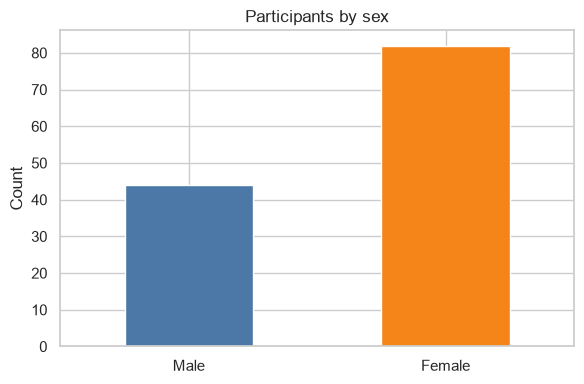

In [2]:
sex_labels = {0: "Male", 1: "Female"}
sex_counts = df["sex"].map(sex_labels).value_counts().reindex(["Male", "Female"])
ax = sex_counts.plot(kind="bar", color=["#4c78a8", "#f58518"], figsize=(6, 4))
ax.set(title="Participants by sex", xlabel="", ylabel="Count")
plt.xticks(rotation=0)
plt.tight_layout()
sex_counts.to_frame("count")

## Numeric distributions

The source contains no weight variable; BMI is available as the body-size measure.

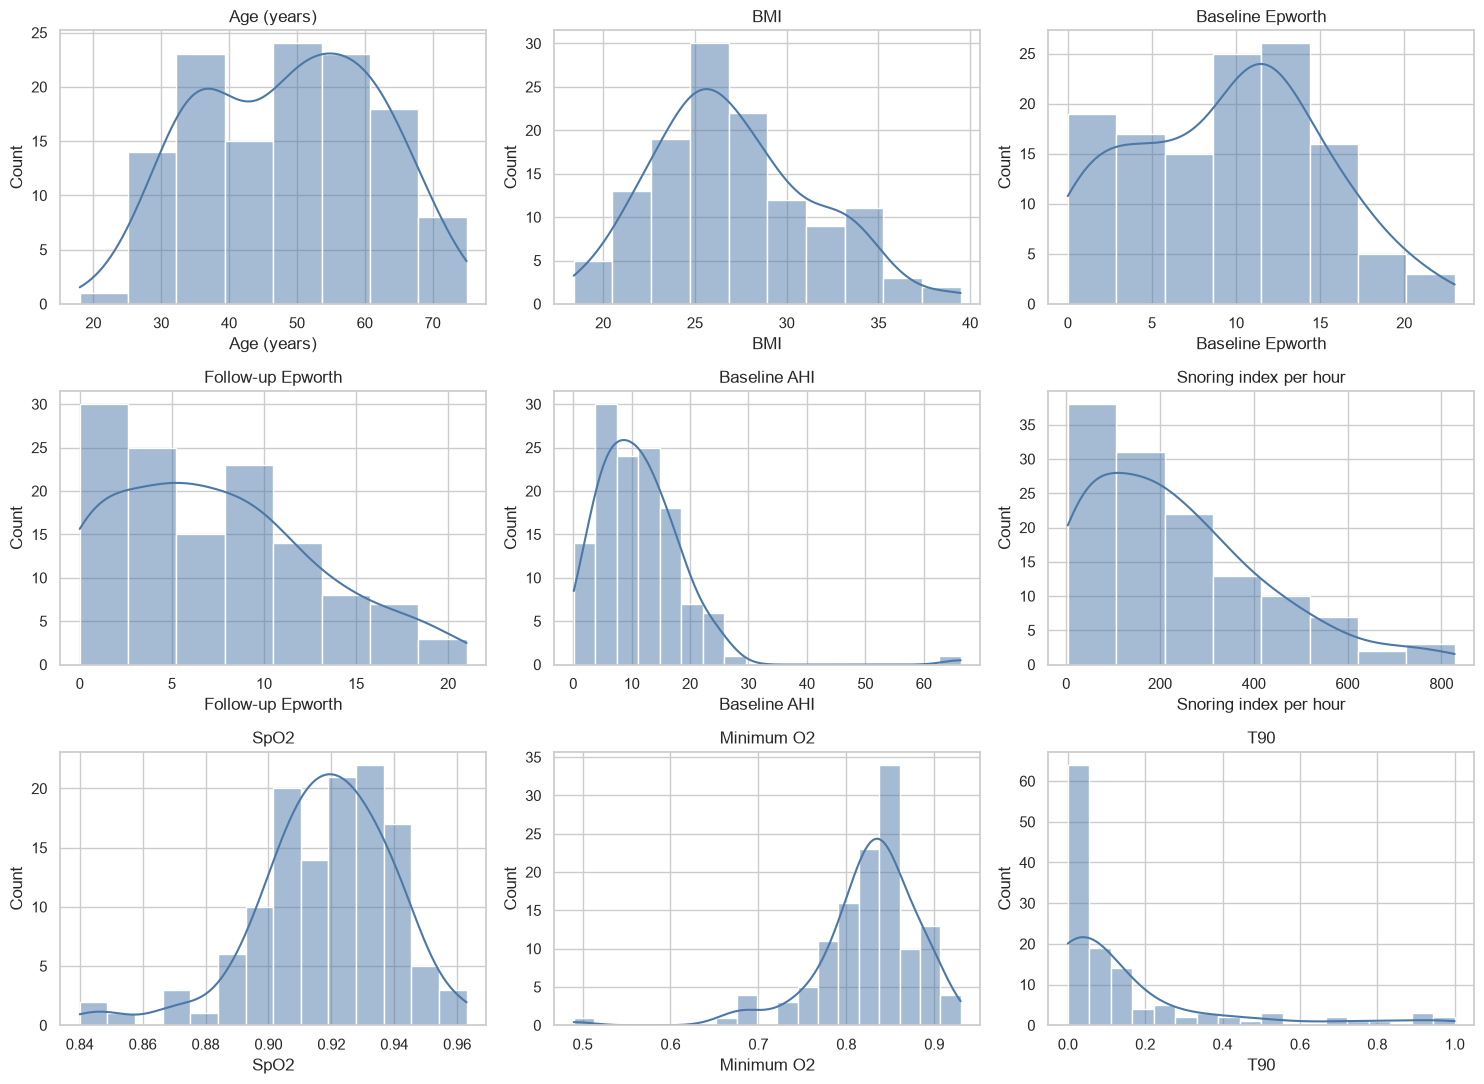

In [3]:
numeric_columns = {
    "age": "Age (years)",
    "bmi": "BMI",
    "baseline_epworth": "Baseline Epworth",
    "followup_epworth": "Follow-up Epworth",
    "baseline_ahi": "Baseline AHI",
    "snoring_index_per_hour": "Snoring index per hour",
    "spo2": "SpO2",
    "minimum_o2": "Minimum O2",
    "t90": "T90",
}
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, (column, label) in zip(axes.flat, numeric_columns.items()):
    sns.histplot(df[column].dropna(), kde=True, ax=ax, color="#4c78a8")
    ax.set(title=label, xlabel=label, ylabel="Count")
plt.tight_layout()

## Sex-discriminated box plots with sample dots

Each box shows the interquartile range and median for men and women. The
jittered dots represent individual observations. Weight is not present in the
source CSV, so no weight plot is fabricated.

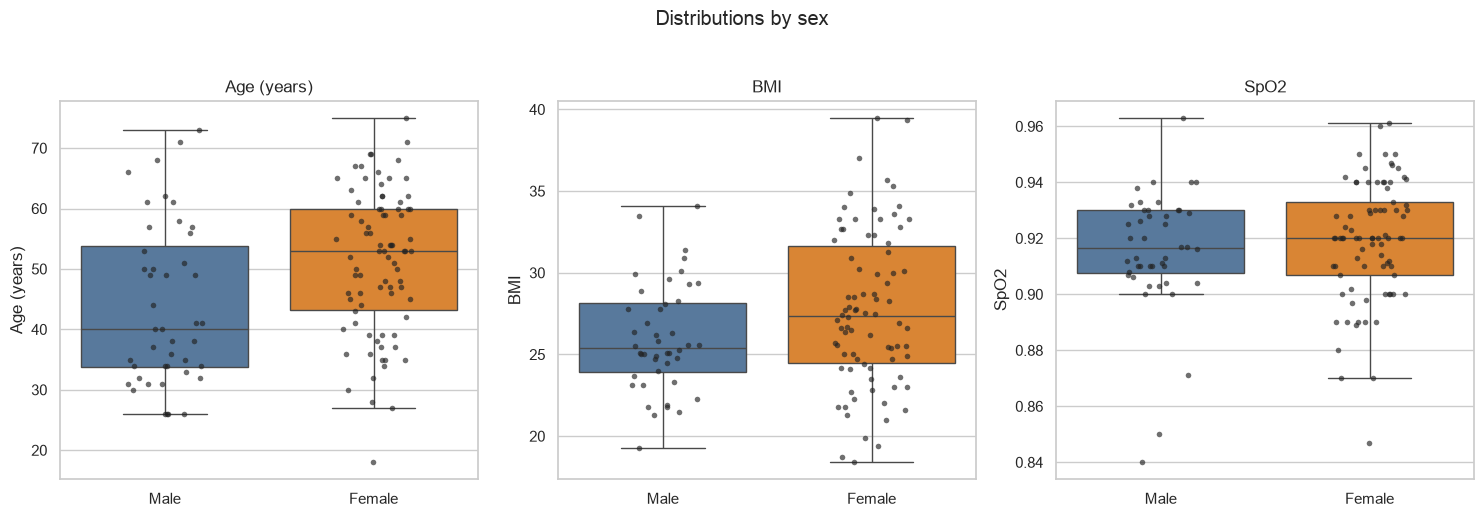

In [4]:
boxplot_columns = {
    "age": "Age (years)",
    "bmi": "BMI",
    "spo2": "SpO2",
}
plot_df = df.copy()
plot_df["sex_label"] = plot_df["sex"].map({0: "Male", 1: "Female"})
sex_order = ["Male", "Female"]
palette = {"Male": "#4c78a8", "Female": "#f58518"}

fig, axes = plt.subplots(1, len(boxplot_columns), figsize=(15, 5))
for ax, (column, label) in zip(axes, boxplot_columns.items()):
    values = plot_df[["sex_label", column]].dropna()
    sns.boxplot(
        data=values,
        x="sex_label",
        y=column,
        order=sex_order,
        hue="sex_label",
        hue_order=sex_order,
        palette=palette,
        showfliers=False,
        legend=False,
        ax=ax,
    )
    sns.stripplot(
        data=values,
        x="sex_label",
        y=column,
        order=sex_order,
        color="#222222",
        alpha=0.65,
        jitter=0.18,
        size=4,
        ax=ax,
    )
    ax.set(title=label, xlabel="", ylabel=label)
fig.suptitle("Distributions by sex", y=1.03)
plt.tight_layout()

In [5]:
summary = df[list(numeric_columns)].describe().T
summary["iqr"] = summary["75%"] - summary["25%"]
summary.round(3)

,count,mean,std,min,25%,50%,75%,max,iqr
age,126.0,48.651,12.844,18.00,37.250,49.500,59.000,75.000,21.750
bmi,126.0,27.135,4.363,18.40,24.250,26.450,29.900,39.480,5.650
baseline_epworth,126.0,9.444,5.656,0.00,5.000,10.000,13.000,23.000,8.000
followup_epworth,125.0,7.200,5.461,0.00,3.000,7.000,11.000,21.000,8.000
baseline_ahi,126.0,11.248,7.814,0.10,6.000,10.300,15.375,66.300,9.375
snoring_index_per_hour,126.0,231.404,188.333,3.50,69.250,192.050,328.950,828.300,259.700
spo2,125.0,0.918,0.022,0.84,0.907,0.920,0.930,0.963,0.023
minimum_o2,125.0,0.826,0.059,0.49,0.800,0.830,0.860,0.930,0.060
t90,126.0,0.148,0.234,0.00,0.007,0.048,0.154,1.000,0.146
